# Naive Bayes Classification – NBA Player Longevity Prediction

## Load Data and Explore Dataset

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)

df = pd.read_csv(r"/mnt/data/extracted_nba_players_data(2).csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1340, 11)


,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


## Target Variable and Class Balance

In [2]:

print(df['target_5yrs'].value_counts())
print()
print(df['target_5yrs'].value_counts(normalize=True))


target_5yrs
1    831
0    509
Name: count, dtype: int64

target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64


## Correlation Heatmap

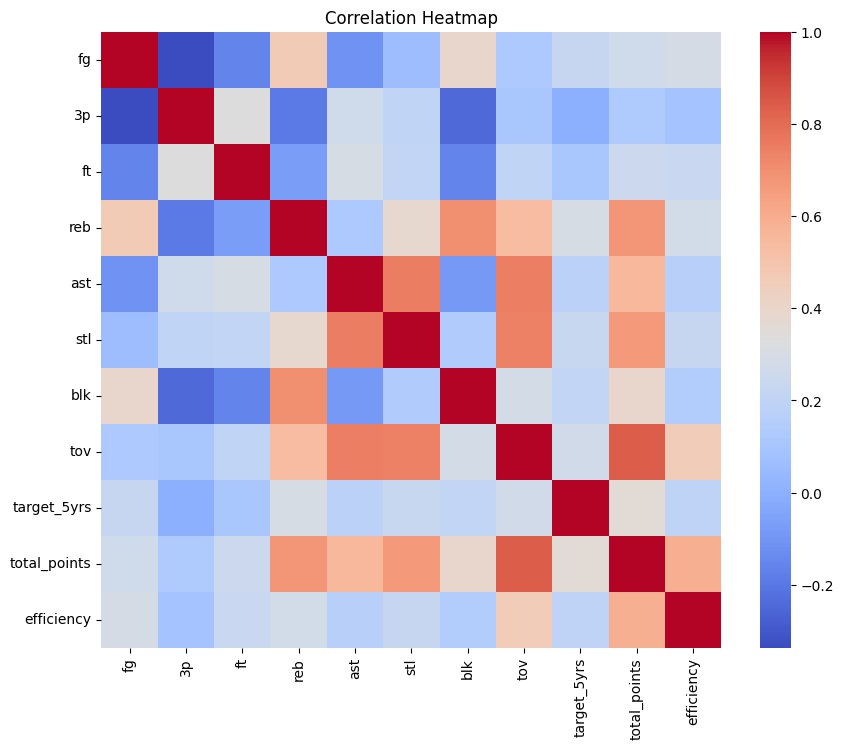

In [3]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## Train-Test Split and Model Training

In [4]:

X = df.drop(columns=['target_5yrs'])
y = df['target_5yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.52      0.77      0.62       102
           1       0.80      0.55      0.65       166

    accuracy                           0.64       268
   macro avg       0.66      0.66      0.64       268
weighted avg       0.69      0.64      0.64       268

Precision: 0.8
Recall: 0.5542168674698795


## Confusion Matrix

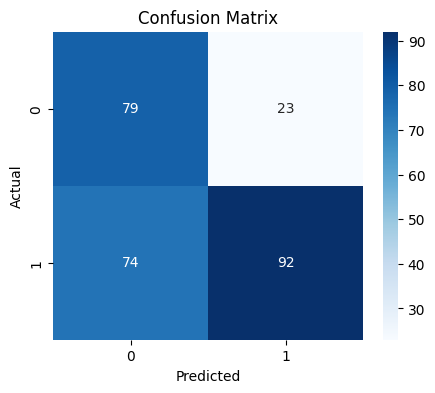

In [5]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## ROC Curve and AUC

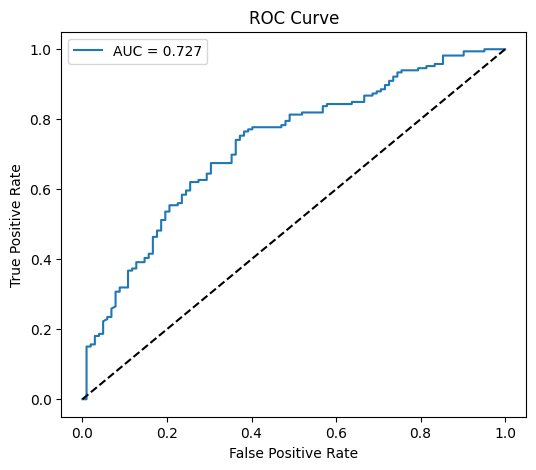

AUC Score: 0.7270257500590598


In [6]:

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)


## Feature Influence Analysis

total_points    277.846119
fg                2.774396
ft                2.242452
reb               1.322181
ast               0.564027
tov               0.431592
3p                0.391684
stl               0.208053
blk               0.191858
efficiency        0.037852
dtype: float64


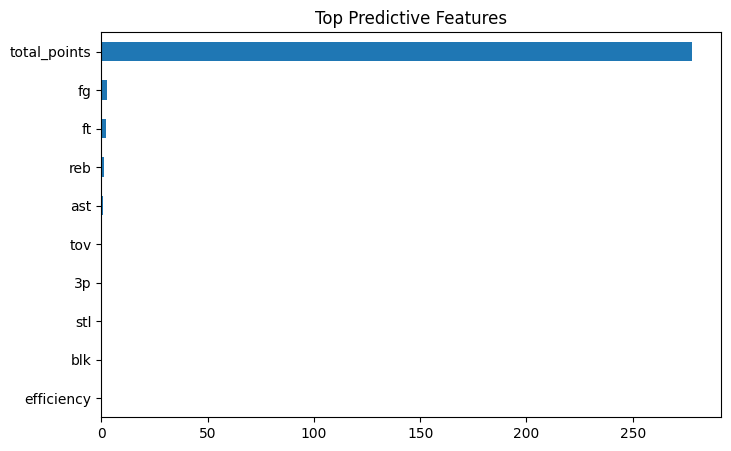

In [7]:

class0_mean = X_train[y_train==0].mean()
class1_mean = X_train[y_train==1].mean()

feature_importance = abs(class1_mean-class0_mean).sort_values(ascending=False)

top10 = feature_importance.head(10)
print(top10)

plt.figure(figsize=(8,5))
top10.sort_values().plot(kind='barh')
plt.title("Top Predictive Features")
plt.show()


# Independence Assumption

Gaussian Naive Bayes assumes that features are conditionally independent.

This assumption is unrealistic in basketball because variables such as points, minutes played and field goals are naturally correlated. Nevertheless, Naive Bayes remains a strong and interpretable baseline model.


# Scouting Department Summary

### Strengths
- Fast and interpretable.
- Good baseline model.
- Useful for preliminary screening.

### Limitations
- Assumes feature independence.
- May miss complex interactions.

### Recommendation
Use the model alongside human scouting rather than as a replacement.
